# Reranker Step 3 — LambdaMART Training, Optuna Tune, Blend & Selection


## 1. Configuration

In [2]:
import os

# ── Paths ──────────────────────────────────────────────────────────────
PHASE3_DIR = "phase3_outputs"
os.makedirs(PHASE3_DIR, exist_ok=True)

VALID_FEATURES_FILE = os.path.join(PHASE3_DIR, "valid_lambdamart_features.parquet")
TEST_FEATURES_FILE  = os.path.join(PHASE3_DIR, "test_lambdamart_features.parquet")

MODEL_BEST_FILE     = os.path.join(PHASE3_DIR, "lambdamart_model_best.txt")
TEST_PREDS_FILE     = os.path.join(PHASE3_DIR, "test_predictions_final.parquet")
ABLATION_CSV        = os.path.join(PHASE3_DIR, "ablation_results.csv")
OPTUNA_TRIALS_CSV   = os.path.join(PHASE3_DIR, "optuna_trials.csv")
BETA_SWEEP_CSV      = os.path.join(PHASE3_DIR, "beta_sweep_results.csv")
FINAL_SUMMARY_CSV   = os.path.join(PHASE3_DIR, "final_summary.csv")

# ── Default LambdaMART params (used during ablation) ───────────────────
LGBM_PARAMS_DEFAULT = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [5, 10, 20],
    "lambdarank_truncation_level": 20,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 200,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq": 5,
    "verbose": -1,
    "seed": 42,
    "num_threads": -1,
}
NUM_BOOST_ROUND       = 800     # full budget (used for ablation + final retrain)
EARLY_STOPPING_ROUNDS = 30
LOG_EVERY             = 100

# ── Optuna tune budget ─────────────────────────────────────────────────
N_OPTUNA_TRIALS         = 30
TUNE_NUM_BOOST_ROUND    = 300   # cap per trial — keeps trial budget manageable
TUNE_EARLY_STOPPING     = 20

# ── Beta blend sweep grid ─────────────────────────────────────────────
BETA_GRID = [0.0, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00]

# ── Split + eval ──────────────────────────────────────────────────────
INNER_TRAIN_FRAC = 0.80
SEED             = 42
EVAL_KS          = [5, 10, 20]
SELECTION_METRIC = "NDCG@10"   # inner-eval selection criterion


## 2. Imports

In [3]:
# !pip install optuna lightgbm  # uncomment if not installed

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna

print(f"lightgbm version: {lgb.__version__}")
print(f"optuna version:   {optuna.__version__}")

warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
optuna.logging.set_verbosity(optuna.logging.WARNING)   # quiet trial logs

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
pd.set_option("display.max_columns", 50)


lightgbm version: 4.6.0
optuna version:   4.8.0


## 3. Load feature files from NB2

In [4]:
t0 = time.time()
valid_df = pd.read_parquet(VALID_FEATURES_FILE)
test_df  = pd.read_parquet(TEST_FEATURES_FILE)
print(f"Valid: {valid_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"Columns ({len(valid_df.columns)}): {list(valid_df.columns)}")
print(f"Load: {time.time()-t0:.1f}s")


Valid: (50000000, 28)
Test:  (25000000, 28)
Columns (28): ['user_idx', 'candidate_item_idx', 'true_item_idx', 'is_positive', 'lightgcn_score', 'lightgcn_rank', 'lightgcn_score_zscore', 'hotel_review_count_log', 'hotel_bayesian_avg', 'hotel_avg_value_damped', 'hotel_avg_location_damped', 'hotel_avg_sleep_damped', 'user_avg_rating', 'user_review_count_log', 'user_rating_std', 'user_avg_value', 'user_avg_location', 'user_avg_sleep', 'candidate_rating_minus_user_avg', 'candidate_pop_minus_user_avg_pop', 'candidate_cofreq_log', 'candidate_cofreq_normalized', 'delta_value', 'delta_location', 'delta_sleep', 'candidate_geo_seen_by_user', 'user_history_count_in_candidate_geo', 'hotel_popularity_in_geo']
Load: 3.5s


## 4. Build ablation groups (A → F)

| Group | Section added | Cumulative |
|-------|--------------|:----------:|
| A | Retrieval (Section 1) | 3 |
| B | + User × hotel cross (Section 5) | 7 |
| C | + Geographic (Section 7) | 10 |
| D | + Hotel quality (Section 2) | 15 |
| E | + User profile (Section 3) | 18 |
| F | + User aspects + Deltas (Sections 4, 6) | 24 |


In [5]:
# Section definitions (mirror the FEATURE_COLS layout in NB2 v3)
SEC_RETRIEVAL = [
    "lightgcn_score",
    "lightgcn_rank",
    "lightgcn_score_zscore",
]
SEC_HOTEL_QUALITY = [
    "hotel_review_count_log",
    "hotel_bayesian_avg",
    "hotel_avg_value_damped",
    "hotel_avg_location_damped",
    "hotel_avg_sleep_damped",
]
SEC_USER_PROFILE = [
    "user_avg_rating",
    "user_review_count_log",
    "user_rating_std",
]
SEC_USER_ASPECTS = [
    "user_avg_value",
    "user_avg_location",
    "user_avg_sleep",
]
SEC_USER_HOTEL_CROSS = [
    "candidate_rating_minus_user_avg",
    "candidate_pop_minus_user_avg_pop",
    "candidate_cofreq_log",
    "candidate_cofreq_normalized",
]
SEC_DELTAS = [
    "delta_value",
    "delta_location",
    "delta_sleep",
]
SEC_GEO = [
    "candidate_geo_seen_by_user",
    "user_history_count_in_candidate_geo",
    "hotel_popularity_in_geo",
]

# Ablation: each group adds ONE section to the previous.
# Order chosen by expected impact (strongest first):
#   retrieval → cross → geo → hotel quality → user profile → aspects+deltas
GROUP_A = list(SEC_RETRIEVAL)
GROUP_B = GROUP_A + SEC_USER_HOTEL_CROSS
GROUP_C = GROUP_B + SEC_GEO
GROUP_D = GROUP_C + SEC_HOTEL_QUALITY
GROUP_E = GROUP_D + SEC_USER_PROFILE
GROUP_F = GROUP_E + SEC_USER_ASPECTS + SEC_DELTAS

FEATURE_GROUPS = {
    "A": GROUP_A,
    "B": GROUP_B,
    "C": GROUP_C,
    "D": GROUP_D,
    "E": GROUP_E,
    "F": GROUP_F,
}

# Verify all features actually exist in the parquets
present = set(valid_df.columns)
missing = sorted(set(GROUP_F) - present)
if missing:
    raise RuntimeError(f"Features missing from valid parquet: {missing}")

print("Ablation groups:")
for name, feats in FEATURE_GROUPS.items():
    print(f"  {name} ({len(feats):2d} features)")
print()
print(f"Group F (full set, {len(GROUP_F)} features):")
for f in GROUP_F:
    print(f"  - {f}")


Ablation groups:
  A ( 3 features)
  B ( 7 features)
  C (10 features)
  D (15 features)
  E (18 features)
  F (24 features)

Group F (full set, 24 features):
  - lightgcn_score
  - lightgcn_rank
  - lightgcn_score_zscore
  - candidate_rating_minus_user_avg
  - candidate_pop_minus_user_avg_pop
  - candidate_cofreq_log
  - candidate_cofreq_normalized
  - candidate_geo_seen_by_user
  - user_history_count_in_candidate_geo
  - hotel_popularity_in_geo
  - hotel_review_count_log
  - hotel_bayesian_avg
  - hotel_avg_value_damped
  - hotel_avg_location_damped
  - hotel_avg_sleep_damped
  - user_avg_rating
  - user_review_count_log
  - user_rating_std
  - user_avg_value
  - user_avg_location
  - user_avg_sleep
  - delta_value
  - delta_location
  - delta_sleep


## 5. Train / inner-eval split on valid

User-level 80/20 split on `valid_df`. Training filtered to users with ≥1 positive (LambdaMART can't learn from all-zero groups)

In [6]:
def user_level_split(df, frac_train, seed):
    unique_users = df["user_idx"].unique()
    rng_local = np.random.default_rng(seed)
    rng_local.shuffle(unique_users)
    n_train = int(len(unique_users) * frac_train)
    train_users = set(unique_users[:n_train].tolist())
    mask = df["user_idx"].isin(train_users)
    return df[mask].copy(), df[~mask].copy()


inner_train_df, inner_eval_df = user_level_split(valid_df, INNER_TRAIN_FRAC, SEED)

# Filter train to users with at least one positive
train_has_pos = inner_train_df.groupby("user_idx")["is_positive"].max()
train_users_with_pos = set(train_has_pos[train_has_pos == 1].index.tolist())
inner_train_filtered_df = inner_train_df[
    inner_train_df["user_idx"].isin(train_users_with_pos)
].copy()

print(f"Inner train (filtered): {inner_train_filtered_df['user_idx'].nunique():,} users, "
      f"{len(inner_train_filtered_df):,} rows")
print(f"Inner eval (all):       {inner_eval_df['user_idx'].nunique():,} users, "
      f"{len(inner_eval_df):,} rows")
print(f"Test (final report):    {test_df['user_idx'].nunique():,} users, "
      f"{len(test_df):,} rows")


Inner train (filtered): 11,817 users, 11,817,000 rows
Inner eval (all):       10,000 users, 10,000,000 rows
Test (final report):    25,000 users, 25,000,000 rows


## 6. LightGBM input helpers, metrics, baseline


In [7]:
def to_lgb_inputs(df, feature_list):
    """Convert candidates to (X, y, group_sizes, sorted_df, init_score) for LightGBM ranking."""
    df_sorted = df.sort_values(
        ["user_idx", "lightgcn_rank"], kind="stable"
    ).reset_index(drop=True)
    X = df_sorted[feature_list].to_numpy(dtype=np.float32)
    y = df_sorted["is_positive"].to_numpy(dtype=np.int32)
    group_sizes = df_sorted.groupby("user_idx", sort=False).size().to_numpy()
    init_score = df_sorted["lightgcn_score"].to_numpy(dtype=np.float64)
    return X, y, group_sizes, df_sorted, init_score


def compute_metrics(df, score_col, ks=EVAL_KS):
    """HR@K and NDCG@K using score_col to rank within each user.

    Single positive per user: NDCG@K = 1/log2(pos+2) if positive in top-K else 0.
    """
    sorted_df = df.sort_values(
        ["user_idx", score_col], ascending=[True, False], kind="stable"
    )
    sorted_df["_pos"] = sorted_df.groupby("user_idx").cumcount()
    n_users = sorted_df["user_idx"].nunique()

    out = {}
    pos_rows = sorted_df[sorted_df["is_positive"] == 1]
    for k in ks:
        in_topk = pos_rows[pos_rows["_pos"] < k]
        out[f"HR@{k}"]   = len(in_topk) / n_users
        out[f"NDCG@{k}"] = float(
            (1.0 / np.log2(in_topk["_pos"].to_numpy() + 2)).sum() / n_users
        )
    return out


baseline_inner = compute_metrics(inner_eval_df, "lightgcn_score")
baseline_test  = compute_metrics(test_df,       "lightgcn_score")
print(f"Baseline inner: {baseline_inner}")
print(f"Baseline test:  {baseline_test}")


Baseline inner: {'HR@5': 0.0106, 'NDCG@5': 0.0065732822561532685, 'HR@10': 0.0187, 'NDCG@10': 0.009180510056623535, 'HR@20': 0.0297, 'NDCG@20': 0.011923438427537042}
Baseline test:  {'HR@5': 0.0106, 'NDCG@5': 0.0065325586081208045, 'HR@10': 0.01744, 'NDCG@10': 0.00873162663371072, 'HR@20': 0.0286, 'NDCG@20': 0.011514257324542936}


## 7. Training and scoring functions

In [8]:
def train_one(feature_list, group_name, params=None,
              num_boost_round=None, early_stopping_rounds=None,
              verbose=True):
    params = params or LGBM_PARAMS_DEFAULT
    num_boost_round = num_boost_round or NUM_BOOST_ROUND
    early_stopping_rounds = early_stopping_rounds or EARLY_STOPPING_ROUNDS

    t0 = time.time()
    if verbose:
        print("=" * 80)
        print(f"TRAINING MODEL {group_name}  ({len(feature_list)} features)")
        print("=" * 80)

    X_tr, y_tr, g_tr, _, init_tr = to_lgb_inputs(inner_train_filtered_df, feature_list)
    X_ev, y_ev, g_ev, _, init_ev = to_lgb_inputs(inner_eval_df,          feature_list)

    train_set = lgb.Dataset(
        X_tr, label=y_tr, group=g_tr, init_score=init_tr,
        feature_name=feature_list, free_raw_data=False,
    )
    eval_set = lgb.Dataset(
        X_ev, label=y_ev, group=g_ev, init_score=init_ev, reference=train_set,
        feature_name=feature_list, free_raw_data=False,
    )

    callbacks = [lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False)]
    if verbose:
        callbacks.append(lgb.log_evaluation(period=LOG_EVERY))

    history = {}
    callbacks.append(lgb.record_evaluation(history))

    model = lgb.train(
        params, train_set,
        num_boost_round=num_boost_round,
        valid_sets=[eval_set], valid_names=["eval"],
        callbacks=callbacks,
    )
    train_time = time.time() - t0
    if verbose:
        print(f"Model {group_name}  best_iter={model.best_iteration}  time={train_time:.1f}s")
    return model, history, train_time


def score_with_model(df, model, feature_list, beta=1.0):
    """Compute final score = lightgcn_score + beta * residual."""
    X = df[feature_list].to_numpy(dtype=np.float32)
    residual = model.predict(X, num_iteration=model.best_iteration)
    scored = df.copy()
    scored["pred"]     = df["lightgcn_score"].to_numpy() + beta * residual
    scored["residual"] = residual
    return scored


## 8. Run the A → F ablation


In [10]:
results = {}

for group_name, feature_list in FEATURE_GROUPS.items():
    model, history, train_time = train_one(feature_list, group_name)

    inner_scored = score_with_model(inner_eval_df, model, feature_list, beta=1.0)
    test_scored  = score_with_model(test_df,       model, feature_list, beta=1.0)

    results[group_name] = {
        "model":       model,
        "history":     history,
        "train_time":  train_time,
        "features":    feature_list,
        "best_iter":   model.best_iteration,
        "inner_eval":  compute_metrics(inner_scored, "pred"),
        "test":        compute_metrics(test_scored,  "pred"),
    }
    print(f"  {group_name} inner: {results[group_name]['inner_eval']}")
    print(f"  {group_name} test:  {results[group_name]['test']}\n")


TRAINING MODEL A  (3 features)
Model A  best_iter=1  time=4.8s
  A inner: {'HR@5': 0.0102, 'NDCG@5': 0.006187740589886573, 'HR@10': 0.0184, 'NDCG@10': 0.008836459447881362, 'HR@20': 0.03, 'NDCG@20': 0.011710140031794205}
  A test:  {'HR@5': 0.01036, 'NDCG@5': 0.006316661290637989, 'HR@10': 0.01724, 'NDCG@10': 0.00853289942963189, 'HR@20': 0.02832, 'NDCG@20': 0.011296189133894418}

TRAINING MODEL B  (7 features)
Model B  best_iter=14  time=7.8s
  B inner: {'HR@5': 0.013, 'NDCG@5': 0.008073573848521573, 'HR@10': 0.0224, 'NDCG@10': 0.011078630387715374, 'HR@20': 0.0369, 'NDCG@20': 0.014702245387260808}
  B test:  {'HR@5': 0.0116, 'NDCG@5': 0.007545453947962228, 'HR@10': 0.01948, 'NDCG@10': 0.010088597504101246, 'HR@20': 0.0314, 'NDCG@20': 0.013069342717659983}

TRAINING MODEL C  (10 features)
Model C  best_iter=18  time=9.2s
  C inner: {'HR@5': 0.0146, 'NDCG@5': 0.009216873721903615, 'HR@10': 0.0247, 'NDCG@10': 0.012489055333936044, 'HR@20': 0.0379, 'NDCG@20': 0.01582321379139991}
  C tes

## 9. Ablation results table

In [11]:
rows = [{
    "model": "Baseline",
    "n_features": 0,
    "best_iter": 0,
    "train_time_s": 0.0,
    **{f"inner_{k}": v for k, v in baseline_inner.items()},
    **{f"test_{k}":  v for k, v in baseline_test.items()},
}]
for g, r in results.items():
    rows.append({
        "model": g,
        "n_features": len(r["features"]),
        "best_iter": r["best_iter"],
        "train_time_s": round(r["train_time"], 1),
        **{f"inner_{k}": v for k, v in r["inner_eval"].items()},
        **{f"test_{k}":  v for k, v in r["test"].items()},
    })

ablation_df = pd.DataFrame(rows)
base_test_ndcg10 = ablation_df.loc[0, "test_NDCG@10"]
ablation_df["test_NDCG@10_lift_pct"] = (
    (ablation_df["test_NDCG@10"] / base_test_ndcg10 - 1) * 100
).round(2)

print("ABLATION RESULTS (default params, beta=1.0)")
print(ablation_df.round(4).to_string(index=False))

ablation_df.to_csv(ABLATION_CSV, index=False)
print(f"\nSaved {ABLATION_CSV}")

# Pick the winner by inner NDCG@10
best_group_name = max(results.keys(), key=lambda g: results[g]["inner_eval"]["NDCG@10"])
best_features   = results[best_group_name]["features"]
print(f"\nBest ablation group by inner {SELECTION_METRIC}: {best_group_name}  ({len(best_features)} features)")


ABLATION RESULTS (default params, beta=1.0)
   model  n_features  best_iter  train_time_s  inner_HR@5  inner_NDCG@5  inner_HR@10  inner_NDCG@10  inner_HR@20  inner_NDCG@20  test_HR@5  test_NDCG@5  test_HR@10  test_NDCG@10  test_HR@20  test_NDCG@20  test_NDCG@10_lift_pct
Baseline           0          0        0.0000      0.0106        0.0066       0.0187         0.0092       0.0297         0.0119     0.0106       0.0065      0.0174        0.0087      0.0286        0.0115                 0.0000
       A           3          1        4.8000      0.0102        0.0062       0.0184         0.0088       0.0300         0.0117     0.0104       0.0063      0.0172        0.0085      0.0283        0.0113                -2.2800
       B           7         14        7.8000      0.0130        0.0081       0.0224         0.0111       0.0369         0.0147     0.0116       0.0075      0.0195        0.0101      0.0314        0.0131                15.5400
       C          10         18        9.2000   

## 10. Optuna hyperparameter tune on the winner

| Param | Range | Why |
|-------|-------|-----|
| `learning_rate` | log-uniform [0.01, 0.1] | Core gradient step |
| `num_leaves` | int [15, 127] | Tree complexity |
| `min_data_in_leaf` | int [50, 500] | Regularization via leaf size |
| `feature_fraction` | uniform [0.6, 1.0] | Per-tree feature subsample |
| `bagging_fraction` | uniform [0.6, 1.0] | Per-tree row subsample |
| `lambdarank_truncation_level` | choice [10, 20, 30] | Where pairwise gradient focus sits |
| `reg_alpha` | uniform [0, 1] | L1 |
| `reg_lambda` | uniform [0, 1] | L2 |



In [12]:
# Pre-build datasets for the winning feature group (one time, reused across trials)
X_tr, y_tr, g_tr, _, init_tr = to_lgb_inputs(inner_train_filtered_df, best_features)
X_ev, y_ev, g_ev, _, init_ev = to_lgb_inputs(inner_eval_df,          best_features)

train_set_tune = lgb.Dataset(
    X_tr, label=y_tr, group=g_tr, init_score=init_tr,
    feature_name=best_features, free_raw_data=False,
)
eval_set_tune = lgb.Dataset(
    X_ev, label=y_ev, group=g_ev, init_score=init_ev, reference=train_set_tune,
    feature_name=best_features, free_raw_data=False,
)


def objective(trial):
    params = {
        "objective": "lambdarank",
        "metric": "ndcg",
        "ndcg_eval_at": [10],
        "lambdarank_truncation_level": trial.suggest_categorical(
            "lambdarank_truncation_level", [10, 20, 30]
        ),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves":       trial.suggest_int  ("num_leaves", 15, 127),
        "min_data_in_leaf": trial.suggest_int  ("min_data_in_leaf", 50, 500),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq":     5,
        "reg_alpha":        trial.suggest_float("reg_alpha",  0.0, 1.0),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.0, 1.0),
        "verbose": -1,
        "seed": SEED,
        "num_threads": -1,
    }

    model = lgb.train(
        params, train_set_tune,
        num_boost_round=TUNE_NUM_BOOST_ROUND,
        valid_sets=[eval_set_tune], valid_names=["eval"],
        callbacks=[lgb.early_stopping(stopping_rounds=TUNE_EARLY_STOPPING, verbose=False)],
    )

    inner_scored = score_with_model(inner_eval_df, model, best_features, beta=1.0)
    metrics = compute_metrics(inner_scored, "pred")
    return metrics["NDCG@10"]


print(f"Running Optuna ({N_OPTUNA_TRIALS} trials, ≤{TUNE_NUM_BOOST_ROUND} rounds each)...")
t0 = time.time()
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
tune_time = time.time() - t0

print(f"\nOptuna finished in {tune_time/60:.1f} min")
print(f"Best inner NDCG@10: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Persist trial history
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "duration", "state"))
trials_df.to_csv(OPTUNA_TRIALS_CSV, index=False)
print(f"\nSaved {OPTUNA_TRIALS_CSV}  ({len(trials_df)} trials)")


Running Optuna (30 trials, ≤300 rounds each)...


  0%|          | 0/30 [00:00<?, ?it/s]


Optuna finished in 8.2 min
Best inner NDCG@10: 0.0143
Best params:
  lambdarank_truncation_level: 30
  learning_rate: 0.01534149770709841
  num_leaves: 60
  min_data_in_leaf: 340
  feature_fraction: 0.8604063212686379
  bagging_fraction: 0.9963240850263088
  reg_alpha: 0.2099193633222757
  reg_lambda: 0.7603114460037732

Saved phase3_outputs\optuna_trials.csv  (30 trials)


## 11. Optuna trial trajectory

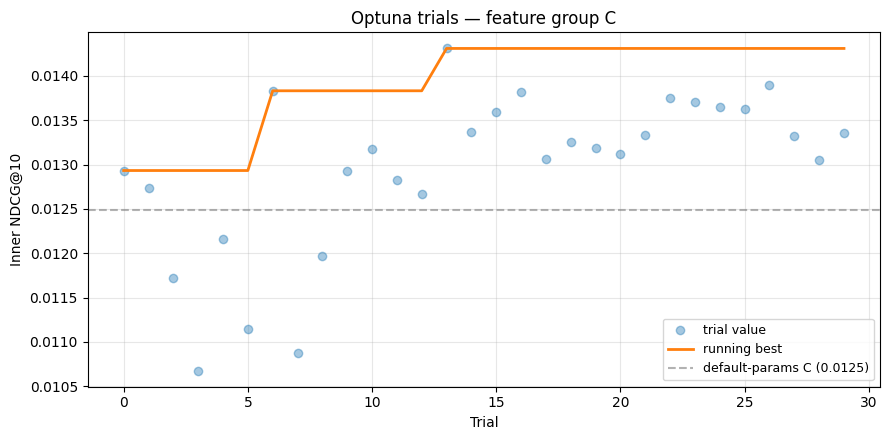

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
trial_values = [t.value for t in study.trials if t.value is not None]
trial_numbers = [t.number for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(trial_values)

ax.plot(trial_numbers, trial_values, "o", alpha=0.4, label="trial value")
ax.plot(trial_numbers, running_best,  "-", linewidth=2, label="running best")
ax.axhline(results[best_group_name]["inner_eval"]["NDCG@10"], linestyle="--",
           color="gray", alpha=0.6,
           label=f"default-params {best_group_name} ({results[best_group_name]['inner_eval']['NDCG@10']:.4f})")
ax.set_xlabel("Trial")
ax.set_ylabel("Inner NDCG@10")
ax.set_title(f"Optuna trials — feature group {best_group_name}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Retrain winner with tuned params at full budget



In [14]:
# Merge best Optuna params with fixed config
TUNED_PARAMS = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [5, 10, 20],
    "bagging_freq": 5,
    "verbose": -1,
    "seed": SEED,
    "num_threads": -1,
    **study.best_params,
}

print("Final tuned params:")
for k, v in TUNED_PARAMS.items():
    print(f"  {k}: {v}")
print()

tuned_model, tuned_history, tuned_train_time = train_one(
    best_features, f"{best_group_name} (tuned)",
    params=TUNED_PARAMS,
    num_boost_round=NUM_BOOST_ROUND,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
)

tuned_inner_scored = score_with_model(inner_eval_df, tuned_model, best_features, beta=1.0)
tuned_test_scored  = score_with_model(test_df,       tuned_model, best_features, beta=1.0)
tuned_inner = compute_metrics(tuned_inner_scored, "pred")
tuned_test  = compute_metrics(tuned_test_scored,  "pred")

print(f"\nTuned {best_group_name} @ beta=1.0:")
print(f"  inner: {tuned_inner}")
print(f"  test:  {tuned_test}")

default_inner_ndcg = results[best_group_name]["inner_eval"]["NDCG@10"]
tuning_lift_pct = (tuned_inner["NDCG@10"] / default_inner_ndcg - 1) * 100
print(f"\nLift from tuning (inner NDCG@10): {tuning_lift_pct:+.2f}%")


Final tuned params:
  objective: lambdarank
  metric: ndcg
  ndcg_eval_at: [5, 10, 20]
  bagging_freq: 5
  verbose: -1
  seed: 42
  num_threads: -1
  lambdarank_truncation_level: 30
  learning_rate: 0.01534149770709841
  num_leaves: 60
  min_data_in_leaf: 340
  feature_fraction: 0.8604063212686379
  bagging_fraction: 0.9963240850263088
  reg_alpha: 0.2099193633222757
  reg_lambda: 0.7603114460037732

TRAINING MODEL C (tuned)  (10 features)
[100]	eval's ndcg@5: 0.717781	eval's ndcg@10: 0.720959	eval's ndcg@20: 0.724192
Model C (tuned)  best_iter=104  time=24.4s

Tuned C @ beta=1.0:
  inner: {'HR@5': 0.0166, 'NDCG@5': 0.011100836110179462, 'HR@10': 0.0266, 'NDCG@10': 0.014309614260736177, 'HR@20': 0.0398, 'NDCG@20': 0.017612686787708418}
  test:  {'HR@5': 0.01328, 'NDCG@5': 0.00838952864230638, 'HR@10': 0.02132, 'NDCG@10': 0.010976863931439835, 'HR@20': 0.03336, 'NDCG@20': 0.014028322082342698}

Lift from tuning (inner NDCG@10): +14.58%


## 13. Beta sweep on tuned winner


In [15]:
sweep_rows = []
for beta in BETA_GRID:
    inner_scored = score_with_model(inner_eval_df, tuned_model, best_features, beta=beta)
    test_scored  = score_with_model(test_df,       tuned_model, best_features, beta=beta)
    m_inner = compute_metrics(inner_scored, "pred")
    m_test  = compute_metrics(test_scored,  "pred")
    sweep_rows.append({
        "beta": beta,
        **{f"inner_{k}": v for k, v in m_inner.items()},
        **{f"test_{k}":  v for k, v in m_test.items()},
    })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(BETA_SWEEP_CSV, index=False)
print(f"BETA SWEEP — tuned model {best_group_name}")
print(sweep_df.round(4).to_string(index=False))
print(f"\nSaved {BETA_SWEEP_CSV}")

best_beta_row = sweep_df.loc[sweep_df["inner_NDCG@10"].idxmax()]
best_beta = float(best_beta_row["beta"])
print(f"\nBest beta by inner NDCG@10: {best_beta}")
print(f"  inner NDCG@10: {best_beta_row['inner_NDCG@10']:.4f}")
print(f"  test  NDCG@10: {best_beta_row['test_NDCG@10']:.4f}")


BETA SWEEP — tuned model C
  beta  inner_HR@5  inner_NDCG@5  inner_HR@10  inner_NDCG@10  inner_HR@20  inner_NDCG@20  test_HR@5  test_NDCG@5  test_HR@10  test_NDCG@10  test_HR@20  test_NDCG@20
0.0000      0.0106        0.0066       0.0187         0.0092       0.0297         0.0119     0.0106       0.0065      0.0174        0.0087      0.0286        0.0115
0.0500      0.0108        0.0067       0.0188         0.0092       0.0299         0.0120     0.0107       0.0066      0.0177        0.0089      0.0286        0.0116
0.1000      0.0110        0.0068       0.0189         0.0093       0.0301         0.0121     0.0108       0.0067      0.0176        0.0089      0.0288        0.0116
0.2500      0.0111        0.0068       0.0193         0.0094       0.0303         0.0122     0.0112       0.0068      0.0178        0.0089      0.0291        0.0118
0.5000      0.0119        0.0075       0.0197         0.0100       0.0311         0.0129     0.0121       0.0075      0.0187        0.0096      0.03

## 14. Plot beta sweep

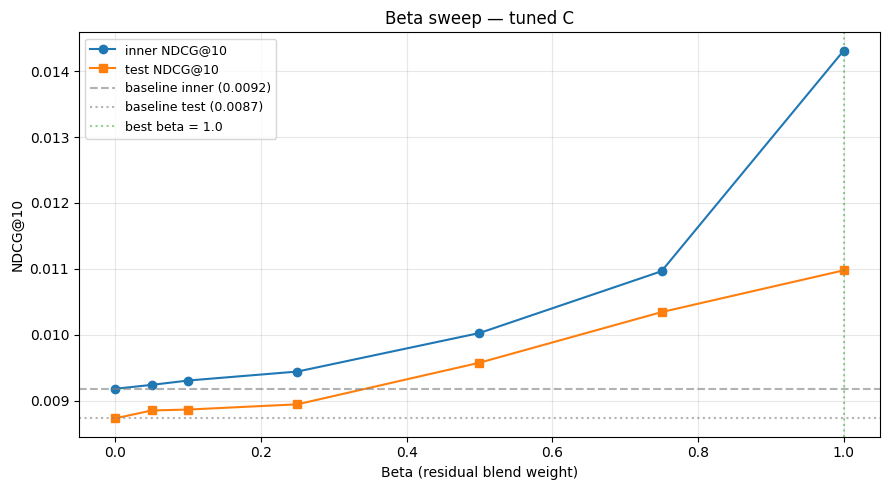

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_df["beta"], sweep_df["inner_NDCG@10"], marker="o", label="inner NDCG@10")
ax.plot(sweep_df["beta"], sweep_df["test_NDCG@10"],  marker="s", label="test NDCG@10")
ax.axhline(baseline_inner["NDCG@10"], linestyle="--", color="gray", alpha=0.6,
           label=f"baseline inner ({baseline_inner['NDCG@10']:.4f})")
ax.axhline(baseline_test["NDCG@10"], linestyle=":", color="gray", alpha=0.6,
           label=f"baseline test ({baseline_test['NDCG@10']:.4f})")
ax.axvline(best_beta, linestyle=":", color="C2", alpha=0.5, label=f"best beta = {best_beta}")
ax.set_xlabel("Beta (residual blend weight)")
ax.set_ylabel("NDCG@10")
ax.set_title(f"Beta sweep — tuned {best_group_name}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 16. Final summary: Baseline vs Default vs Tuned vs Tuned+Best-β

Pulls everything together for the writeup. Each row reports inner + test NDCG@10 / NDCG@20 / HR@10 / HR@20 plus % lift over baseline test NDCG@10.


In [17]:
def metrics_to_dict(metrics, prefix):
    return {f"{prefix}_{k}": v for k, v in metrics.items()}


default_best_inner = results[best_group_name]["inner_eval"]
default_best_test  = results[best_group_name]["test"]

# Test metrics at the chosen beta (already in best_beta_row but rebuild cleanly)
final_test_scored = score_with_model(test_df, tuned_model, best_features, beta=best_beta)
final_test = compute_metrics(final_test_scored, "pred")
final_inner_scored = score_with_model(inner_eval_df, tuned_model, best_features, beta=best_beta)
final_inner = compute_metrics(final_inner_scored, "pred")

summary_rows = [
    {"config": "Baseline (LightGCN)",
     "n_features": 0, "params": "—", "beta": "—",
     **metrics_to_dict(baseline_inner, "inner"),
     **metrics_to_dict(baseline_test,  "test")},
    {"config": f"Best ablation {best_group_name} (default params, β=1.0)",
     "n_features": len(best_features), "params": "default", "beta": 1.0,
     **metrics_to_dict(default_best_inner, "inner"),
     **metrics_to_dict(default_best_test,  "test")},
    {"config": f"{best_group_name} tuned (β=1.0)",
     "n_features": len(best_features), "params": "Optuna", "beta": 1.0,
     **metrics_to_dict(tuned_inner, "inner"),
     **metrics_to_dict(tuned_test,  "test")},
    {"config": f"{best_group_name} tuned + best β ({best_beta})",
     "n_features": len(best_features), "params": "Optuna", "beta": best_beta,
     **metrics_to_dict(final_inner, "inner"),
     **metrics_to_dict(final_test,  "test")},
]
summary_df = pd.DataFrame(summary_rows)
base_test_ndcg10 = baseline_test["NDCG@10"]
summary_df["test_NDCG@10_lift_pct"] = (
    (summary_df["test_NDCG@10"] / base_test_ndcg10 - 1) * 100
).round(2)

# Reorder columns for readability
ordered_cols = (
    ["config", "n_features", "params", "beta"]
    + [c for c in summary_df.columns if c.startswith("inner_")]
    + [c for c in summary_df.columns if c.startswith("test_")]
)
summary_df = summary_df[ordered_cols]

print("FINAL SUMMARY")
print(summary_df.round(4).to_string(index=False))
summary_df.to_csv(FINAL_SUMMARY_CSV, index=False)
print(f"\nSaved {FINAL_SUMMARY_CSV}")


FINAL SUMMARY
                                 config  n_features  params   beta  inner_HR@5  inner_NDCG@5  inner_HR@10  inner_NDCG@10  inner_HR@20  inner_NDCG@20  test_HR@5  test_NDCG@5  test_HR@10  test_NDCG@10  test_HR@20  test_NDCG@20  test_NDCG@10_lift_pct
                    Baseline (LightGCN)           0       —      —      0.0106        0.0066       0.0187         0.0092       0.0297         0.0119     0.0106       0.0065      0.0174        0.0087      0.0286        0.0115                 0.0000
Best ablation C (default params, β=1.0)          10 default 1.0000      0.0146        0.0092       0.0247         0.0125       0.0379         0.0158     0.0122       0.0075      0.0196        0.0099      0.0308        0.0127                13.5000
                        C tuned (β=1.0)          10  Optuna 1.0000      0.0166        0.0111       0.0266         0.0143       0.0398         0.0176     0.0133       0.0084      0.0213        0.0110      0.0334        0.0140                25

## 17. Conditional save

Reranker is accepted only if **tuned winner @ best β** beats the LightGCN baseline on **inner eval NDCG@10**. Otherwise we save predictions using the raw LightGCN score and report LightGCN as the selected model. (Test metrics never enter the selection decision.)


In [18]:
winner_beats_baseline = best_beta_row["inner_NDCG@10"] > baseline_inner["NDCG@10"]

print("=" * 80)
print("MODEL SELECTION")
print("=" * 80)
print(f"Baseline inner NDCG@10:                    {baseline_inner['NDCG@10']:.4f}")
print(f"Tuned {best_group_name} @ β={best_beta} inner NDCG@10:  {best_beta_row['inner_NDCG@10']:.4f}")

cols_to_save = [
    "user_idx", "candidate_item_idx", "true_item_idx", "is_positive",
    "lightgcn_score", "lightgcn_rank", "residual", "pred",
]

if winner_beats_baseline:
    lift_pct = (best_beta_row["inner_NDCG@10"] / baseline_inner["NDCG@10"] - 1) * 100
    print(f"✓ Winner beats baseline by {lift_pct:+.2f}% on inner eval — SAVING reranker")
    tuned_model.save_model(MODEL_BEST_FILE, num_iteration=tuned_model.best_iteration)
    print(f"  Saved {MODEL_BEST_FILE}")

    test_preds = score_with_model(test_df, tuned_model, best_features, beta=best_beta)
    test_preds[cols_to_save].to_parquet(TEST_PREDS_FILE, index=False)
    print(f"  Saved {TEST_PREDS_FILE}  (model={best_group_name}-tuned  beta={best_beta})")

    SELECTED_MODEL = f"{best_group_name}-tuned"
    SELECTED_BETA  = best_beta
    SELECTED_METRICS = {
        "inner_NDCG@10": float(best_beta_row["inner_NDCG@10"]),
        "test_NDCG@10":  float(best_beta_row["test_NDCG@10"]),
        "test_HR@10":    float(best_beta_row["test_HR@10"]),
        "test_NDCG@20":  float(best_beta_row["test_NDCG@20"]),
        "test_HR@20":    float(best_beta_row["test_HR@20"]),
    }
else:
    print("✗ No reranker configuration beats baseline on inner eval")
    print("  → Falling back to LightGCN. NOT saving a reranker model.")
    test_preds = test_df.copy()
    test_preds["residual"] = 0.0
    test_preds["pred"]     = test_preds["lightgcn_score"]
    test_preds[cols_to_save].to_parquet(TEST_PREDS_FILE, index=False)
    print(f"  Saved {TEST_PREDS_FILE}  (baseline)")

    SELECTED_MODEL = "Baseline (LightGCN)"
    SELECTED_BETA  = 0.0
    SELECTED_METRICS = {
        "inner_NDCG@10": baseline_inner["NDCG@10"],
        "test_NDCG@10":  baseline_test["NDCG@10"],
        "test_HR@10":    baseline_test["HR@10"],
        "test_NDCG@20":  baseline_test["NDCG@20"],
        "test_HR@20":    baseline_test["HR@20"],
    }

print(f"\nFinal selected model: {SELECTED_MODEL}")
print(f"Final selected beta:  {SELECTED_BETA}")
print(f"Final test metrics:   {SELECTED_METRICS}")


MODEL SELECTION
Baseline inner NDCG@10:                    0.0092
Tuned C @ β=1.0 inner NDCG@10:  0.0143
✓ Winner beats baseline by +55.87% on inner eval — SAVING reranker
  Saved phase3_outputs\lambdamart_model_best.txt
  Saved phase3_outputs\test_predictions_final.parquet  (model=C-tuned  beta=1.0)

Final selected model: C-tuned
Final selected beta:  1.0
Final test metrics:   {'inner_NDCG@10': 0.014309614260736177, 'test_NDCG@10': 0.010976863931439835, 'test_HR@10': 0.02132, 'test_NDCG@20': 0.014028322082342698, 'test_HR@20': 0.03336}


In [19]:
# Sampled-negatives evaluation: per user, score the positive + 100 random negatives
# drawn from that user's existing candidates in test_df, then compute HR@K / NDCG@K.

NUM_SAMPLED_NEGATIVES = 100

# Score test_df with whichever model was selected in the final-selection cell
if winner_beats_baseline:
    sampled_eval_source_df = score_with_model(test_df, tuned_model, best_features, beta=best_beta)
    eval_label = f"Tuned {best_group_name} (β={best_beta})"
else:
    sampled_eval_source_df = test_df.copy()
    sampled_eval_source_df["pred"] = sampled_eval_source_df["lightgcn_score"]
    eval_label = "LightGCN baseline (fallback)"

rng = np.random.default_rng(SEED)

sampled_pieces = []
n_users_with_pos = 0
n_users_with_enough_negs = 0
n_users_skipped = 0

for user_idx, group in sampled_eval_source_df.groupby("user_idx", sort=False):
    pos = group[group["is_positive"] == 1]
    negs = group[group["is_positive"] == 0]
    if len(pos) == 0:
        n_users_skipped += 1
        continue
    n_users_with_pos += 1
    if len(negs) < NUM_SAMPLED_NEGATIVES:
        n_users_skipped += 1
        continue
    n_users_with_enough_negs += 1
    sampled_negs = negs.sample(
        n=NUM_SAMPLED_NEGATIVES,
        random_state=int(rng.integers(0, 2**31 - 1)),
    )
    sampled_pieces.append(pd.concat([pos, sampled_negs], ignore_index=True))

sampled_df = pd.concat(sampled_pieces, ignore_index=True)
SAMPLED_KS = [1, 5, 10, 20]
sampled_metrics = compute_metrics(sampled_df, "pred", ks=SAMPLED_KS)

# Stash for the chart cell
sampled_metrics["n_users_evaluated"] = n_users_with_enough_negs
sampled_metrics["num_negatives"]     = NUM_SAMPLED_NEGATIVES
sampled_metrics["split_name"]        = "test"
sampled_metrics["model_label"]       = eval_label

print("=" * 80)
print(f"SAMPLED-NEGATIVES EVALUATION — {eval_label}")
print("=" * 80)
print(f"Users with a positive in test_df:                {n_users_with_pos:,}")
print(f"Users with ≥{NUM_SAMPLED_NEGATIVES} negatives (evaluated):           {n_users_with_enough_negs:,}")
print(f"Users skipped (no positive or too few negs):    {n_users_skipped:,}")
print()
print(f"Each evaluated user ranked against 1 positive + {NUM_SAMPLED_NEGATIVES} sampled negatives:")
for k in SAMPLED_KS:
    print(f"  HR@{k:<2}:  {sampled_metrics[f'HR@{k}']:.4f}    "
          f"NDCG@{k:<2}: {sampled_metrics[f'NDCG@{k}']:.4f}")

SAMPLED-NEGATIVES EVALUATION — Tuned C (β=1.0)
Users with a positive in test_df:                6,624
Users with ≥100 negatives (evaluated):           6,624
Users skipped (no positive or too few negs):    18,376

Each evaluated user ranked against 1 positive + 100 sampled negatives:
  HR@1 :  0.0741    NDCG@1 : 0.0741
  HR@5 :  0.2107    NDCG@5 : 0.1424
  HR@10:  0.3096    NDCG@10: 0.1742
  HR@20:  0.4574    NDCG@20: 0.2115


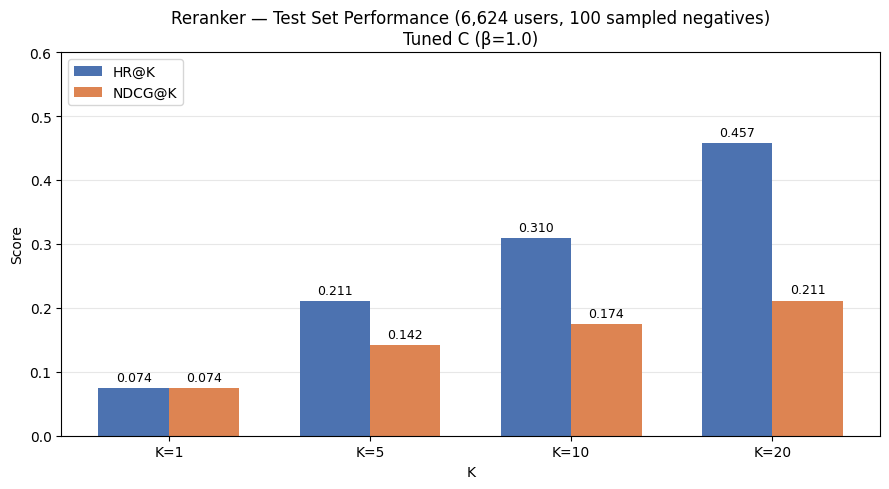

In [21]:
# Bar chart of the sampled-negatives test results — same style as the LightGCN chart

k_values  = [1, 5, 10, 20]
hr_vals   = [sampled_metrics[f"HR@{k}"]   for k in k_values]
ndcg_vals = [sampled_metrics[f"NDCG@{k}"] for k in k_values]

x = np.arange(len(k_values))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_hr   = ax.bar(x - width/2, hr_vals,   width, label="HR@K",   color="#4C72B0")
bars_ndcg = ax.bar(x + width/2, ndcg_vals, width, label="NDCG@K", color="#DD8452")

for bars in (bars_hr, bars_ndcg):
    for b in bars:
        height = b.get_height()
        ax.annotate(
            f"{height:.3f}",
            xy=(b.get_x() + b.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_xlabel("K")
ax.set_ylabel("Score")
ax.set_title(
    f"Reranker — Test Set Performance "
    f"({sampled_metrics['n_users_evaluated']:,} users, "
    f"{sampled_metrics['num_negatives']} sampled negatives)\n"
    f"{sampled_metrics['model_label']}"
)
ax.set_xticks(x)
ax.set_xticklabels([f"K={k}" for k in k_values])
ax.set_ylim(0, 0.6)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()